# 05 - Imitation as PPO Pretraining + Final Discussion (Stage 5 + RQ6)

**Group members:** Marco De Palma, Em Echeverria, Leah Sarouphin, Juan Jose Rincon Briceño, Matteo Mainetti

**Central question: can imitation reduce the sample complexity of PPO?** We compare PPO from scratch vs PPO warm-started from the BC and DAgger students (return vs environment timesteps). These are PPO training runs (heavy), so results are precomputed by `pretraining.py` (runtimes in README) and displayed here.

In [1]:
import sys, os, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from src import seeding, config
seeding.set_seed(0)            # numpy + torch + python random
DEVICE = config.device()
OUT, MODELS, DATA = ROOT/'outputs', ROOT/'models', ROOT/'data'/'demonstrations'
def show(name):
    p = OUT/name
    display(Image(str(p))) if p.exists() else print('precomputed figure not found:', name,
        '- run the corresponding script (see README)')
def results(name):
    p = OUT/name
    return json.load(open(p)) if p.exists() else {}
print('setup ok | seeds set | device', DEVICE)

setup ok | seeds set | device mps


## Sample efficiency: return at a fixed 1.5M-step budget

,env,expert,PPO_scratch,BC_PPO,DAgger_PPO
0,Walker2d,6044,1145,5690,5789
1,Ant,6180,4965,6603,6881


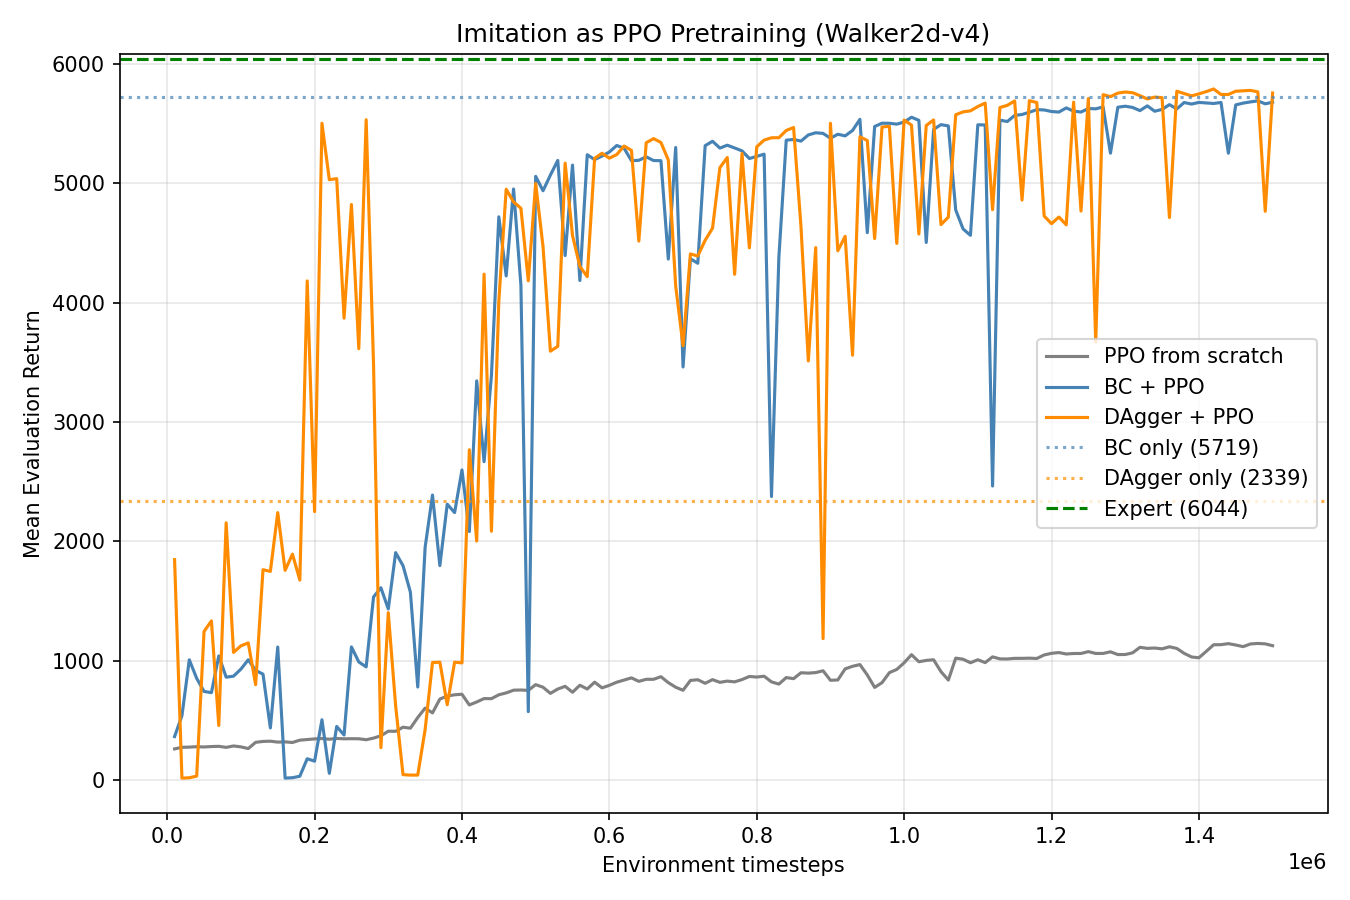

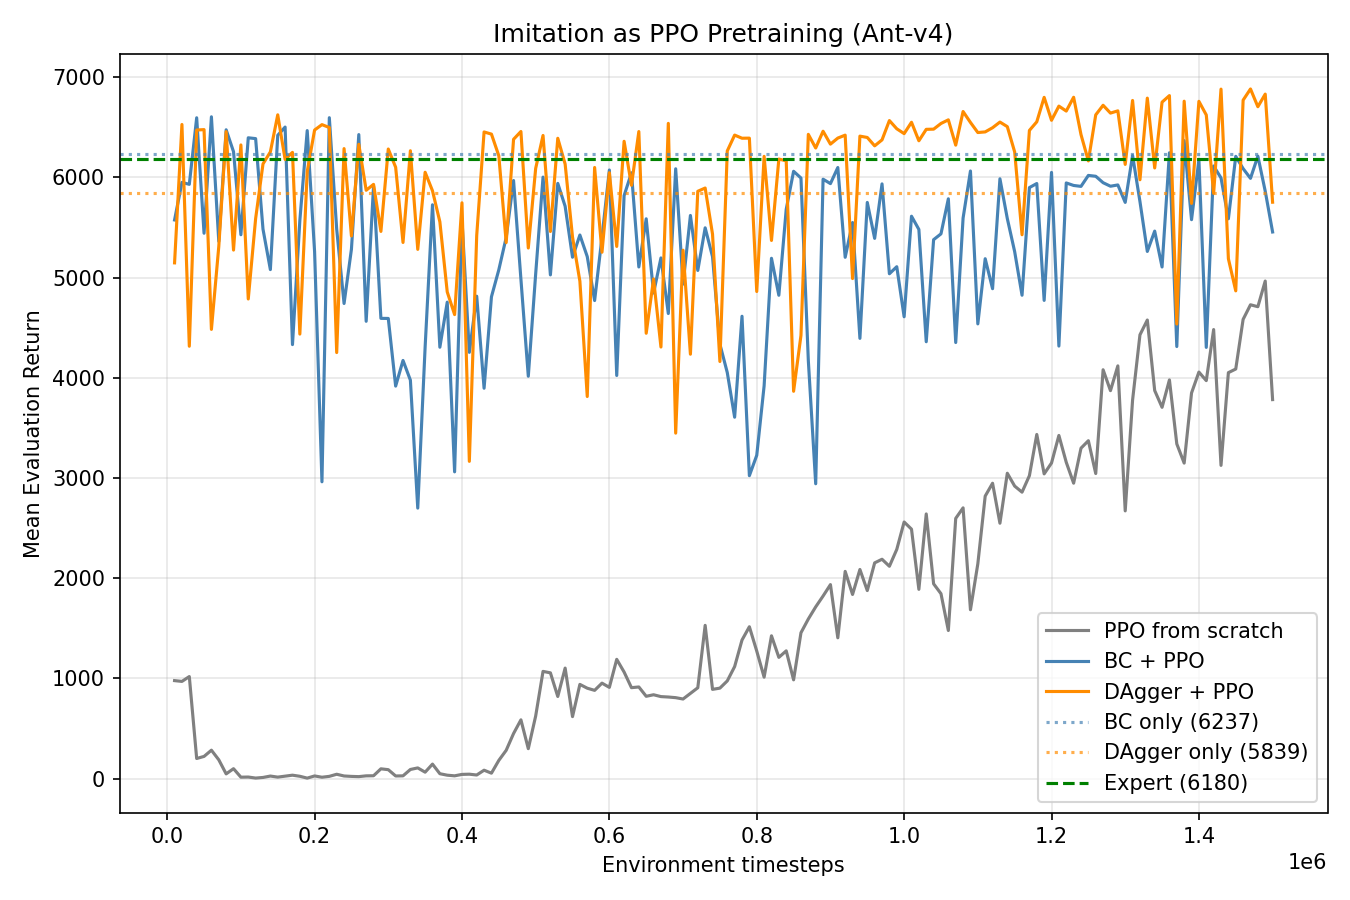

In [2]:
rows=[]
for k,label in {'Walker2d-v4':'Walker2d','Ant-v4':'Ant'}.items():
    d = results(f'pretraining_results_{k}.json')
    if not d: continue
    c=d['curves']; f=lambda n: round(max(c[n]['returns'])) if n in c else None
    rows.append(dict(env=label, expert=round(d['expert_mean']),
        PPO_scratch=f('scratch'), BC_PPO=f('bc_ppo'), DAgger_PPO=f('dagger_ppo')))
display(pd.DataFrame(rows))
show('pretraining_Walker2d-v4.png'); show('pretraining_Ant-v4.png')

**Result: yes, decisively.** At 1.5M steps PPO from scratch lags (Walker2d ~1.1k, Ant ~5.0k) while imitation-pretrained PPO is at/near expert level (Walker2d ~5.7k, Ant ~6.6-6.9k). **Nuance:** under Ant's tiny LR the warm-start holds from step 0; under Walker2d's larger LR the warm-started actor dips early (fresh critic -> noisy advantages) then recovers fast.

## RQ6 - Systematic Walker2d vs Ant differences?

**Yes.** Although Ant is higher-dimensional and 3D, it is *easier to imitate*: BC recovers 99% (vs 95%), the action map fits to MSE ~5e-4, architecture barely matters, and the warm-start is stable. Walker2d is harder to imitate (aggressive near-saturated control compounds errors, needs more training, a larger net, and shows the warm-start dip). Notably, expert *training* difficulty was the opposite (Ant needed the tuned config), so training difficulty and imitation difficulty are distinct.

## Consolidated answers (RQ1-RQ6)

| RQ | Answer | Evidence |
|---|---|---|
| RQ1 | BC reaches 95-99% with enough training; gap from compounding errors | BC table, epoch sweep |
| RQ2 | steep rise then saturation ~50 eps; small data high-variance | ablation |
| RQ3 | lower MSE not sufficient; return varies at fixed MSE | val MSE vs return |
| RQ4 | matters on Walker2d (large wins), tight on Ant | arch sweep |
| RQ5 | DAgger matches/beats BC, reaches expert, corrects covariate shift | DAgger curves |
| RQ6 | Ant easier to imitate though harder to train | cross-env results |

**Central question:** imitation learning substantially reduces PPO sample complexity, both BC and DAgger warm-starts reach near-expert return at a fraction of the from-scratch budget.

## Qualitative comparison (M6 video)

Side-by-side expert (left) vs BC student (right): `videos/expert_vs_student_Walker2d-v4.mp4`, `videos/expert_vs_student_Ant-v4.mp4`.